# Basic Option Positions: Profit and Loss at Expiration

The charts below show profit/loss in option points at expiration. They exclude the contract multiplier, fees, taxes, and margin requirements.

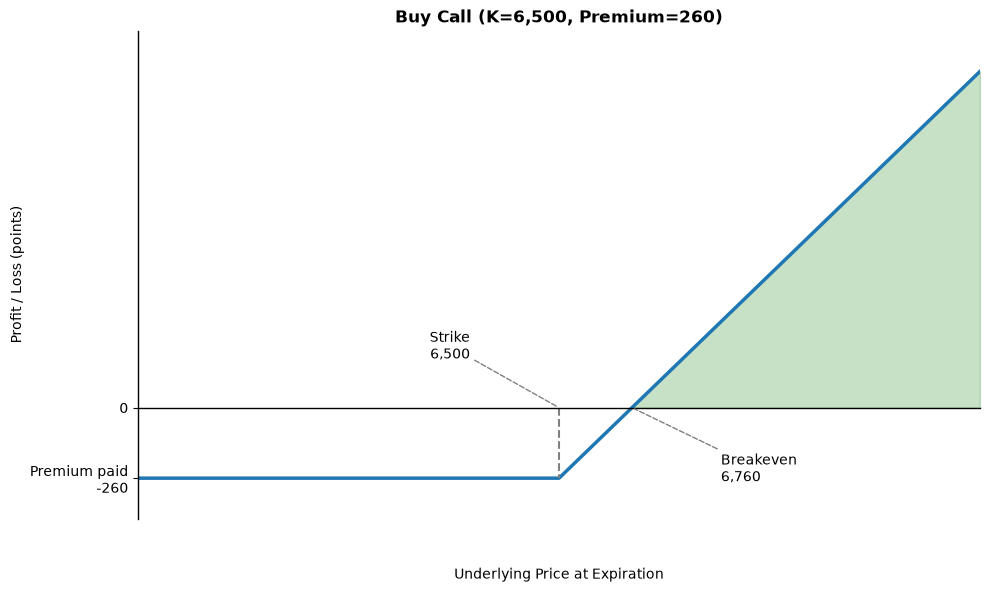

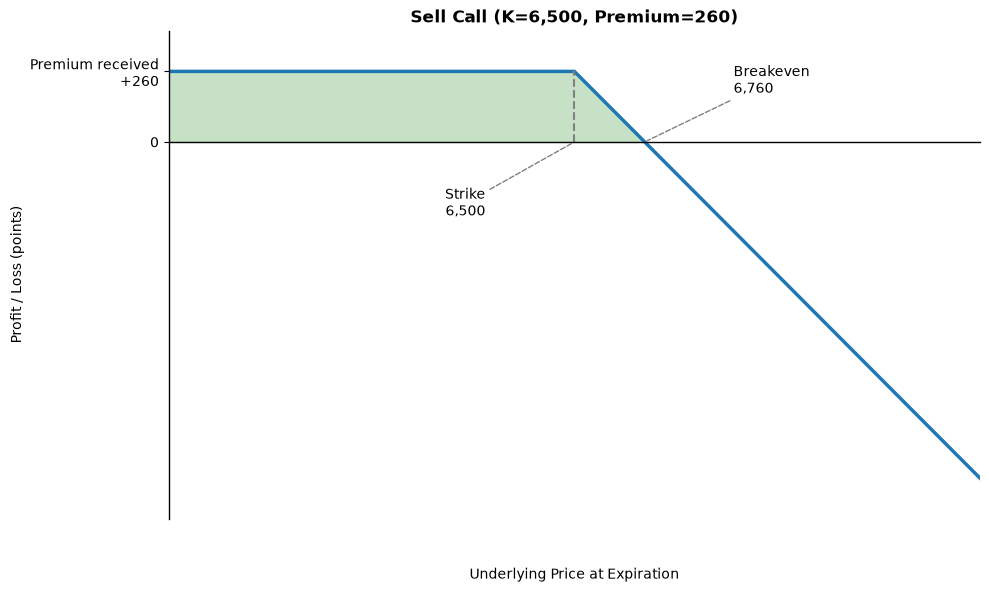

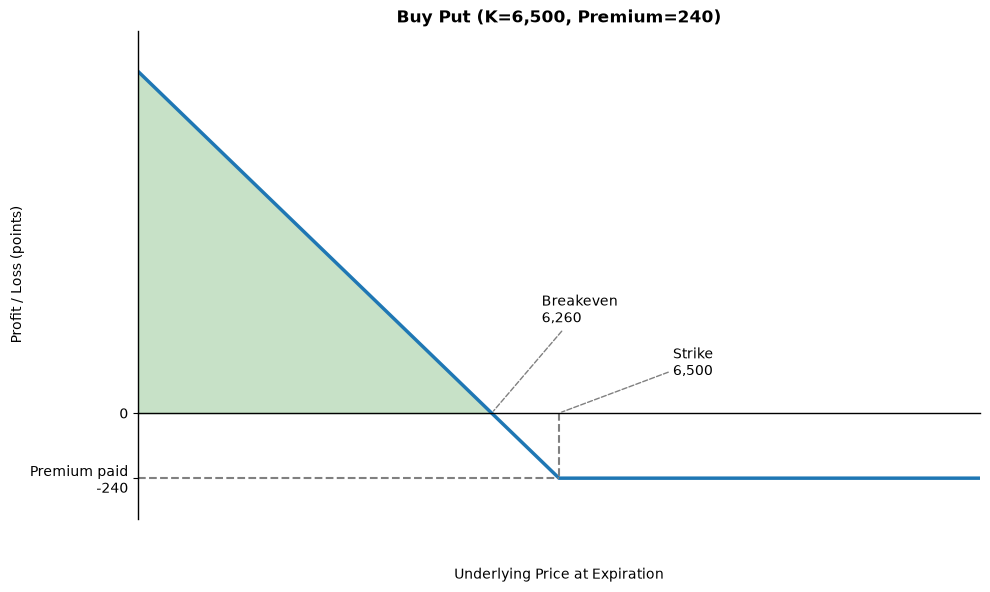

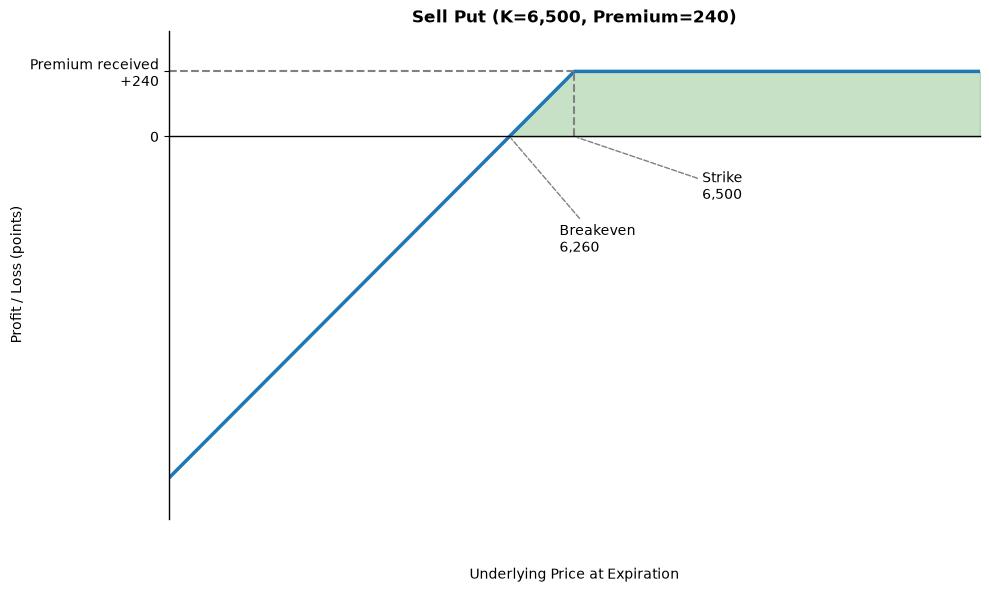

In [136]:
import numpy as np
import matplotlib.pyplot as plt

# Underlying price at expiration
prices = np.linspace(5000, 8000, 3001)


def plot_option_pnl(position, option_type, strike, premium):
    """Draw one independent option profit/loss chart at expiration."""
    if option_type == 'call':
        intrinsic_value = np.maximum(prices - strike, 0)
        breakeven = strike + premium
    elif option_type == 'put':
        intrinsic_value = np.maximum(strike - prices, 0)
        breakeven = strike - premium
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    if position == 'buy':
        pnl = intrinsic_value - premium
        premium_tick = -premium
        premium_label = f'Premium paid\n{premium_tick:+,.0f}'
    elif position == 'sell':
        pnl = premium - intrinsic_value
        premium_tick = premium
        premium_label = f'Premium received\n{premium_tick:+,.0f}'
    else:
        raise ValueError("position must be 'buy' or 'sell'")

    title = f'{position.title()} {option_type.title()} (K={strike:,.0f}, Premium={premium:,.0f})'
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(prices, pnl, color='tab:blue', linewidth=2.5)
    ax.fill_between(prices, 0, pnl, where=pnl > 0, interpolate=True,
                    color='forestgreen', alpha=0.25)
    # Show the premium amount at the strike price without extending the guide line.
    ax.vlines(strike, 0, premium_tick, color='gray', linestyle='--', linewidth=1.5)
    if option_type == 'put':
        ax.hlines(premium_tick, 5000, strike, color='gray', linestyle='--', linewidth=1.5)

    y_padding = (pnl.max() - pnl.min()) * 0.1
    ax.set_xlim(5000, 8000)
    ax.set_ylim(pnl.min() - y_padding, pnl.max() + y_padding)

    ax.set_xticks([])

    y_ticks = sorted(set([premium_tick, 0]))
    y_labels = [premium_label if value == premium_tick else f'{value:,.0f}' for value in y_ticks]
    ax.set_yticks(y_ticks, y_labels)

    if position == 'buy' and option_type == 'call':
        strike_offset, breakeven_offset = (-64, 32), (64, -32)
    elif position == 'sell' and option_type == 'call':
        strike_offset, breakeven_offset = (-64, -32), (64, 32)
    elif position == 'buy' and option_type == 'put':
        strike_offset, breakeven_offset = (82, 24), (36, 62)
    else:  # sell put
        strike_offset, breakeven_offset = (92, -24), (36, -62)

    def add_price_annotation(text, price, offset):
        ax.annotate(
            text, xy=(price, 0), xytext=offset, textcoords='offset points',
            ha='left' if offset[0] > 0 else 'right',
            va='bottom' if offset[1] > 0 else 'top',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=1.5),
            arrowprops=dict(arrowstyle='-', color='gray', linestyle='--', linewidth=1),
        )

    add_price_annotation(f'Strike\n{strike:,.0f}', strike, strike_offset)
    add_price_annotation(f'Breakeven\n{breakeven:,.0f}', breakeven, breakeven_offset)

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Underlying Price at Expiration')
    ax.set_ylabel('Profit / Loss (points)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position(('data', 0))
    ax.spines['bottom'].set_linewidth(1)
    ax.spines['left'].set_linewidth(1)
    ax.xaxis.set_ticks_position('bottom')
    ax.tick_params(axis='x', which='both', length=0)
    ax.xaxis.set_label_coords(0.5, -0.1)
    fig.tight_layout()
    plt.show()


plot_option_pnl('buy', 'call', strike=6500, premium=260)
plot_option_pnl('sell', 'call', strike=6500, premium=260)
plot_option_pnl('buy', 'put', strike=6500, premium=240)
plot_option_pnl('sell', 'put', strike=6500, premium=240)

# 圖表風格 Prompts

```
圖表風格：
1. 每個策略輸出一張獨立 matplotlib figure。
2. 損益線使用藍色（tab:blue），linewidth=2.5。
3. 僅將 P/L > 0 的 profit area 填滿透明綠色（forestgreen，alpha=0.25）。
4. 不要顯示 grid、legend。
5. 不要完整外框；隱藏 top 與 right spines，只保留左側 y-axis 與位於 y=0 的 x-axis。
6. x-axis 位於零損益位置，標示為 Underlying Price at Expiration。
7. y-axis 標示為 Profit / Loss (points)。必須保留 net premium（付出為負、收取為正）與 0 的刻度；若圖中以水平虛線標示最大獲利、最大損失或其他關鍵損益高度，y-axis 也必須加入相同數值的具名刻度。
8. 不使用一般 x-axis tick labels；Strike 與 Breakeven 必須以 annotate 顯示名稱與數字，例如：
   Strike
   6,500
   或
   Breakeven
   6,760
9. 每個 Strike／Breakeven label 使用無邊框、半透明白底，並以灰色虛線引導線連至正確的 `(price, 0)` 位置。
10. annotation 必須使用與策略名稱無關的通用碰撞排除流程，不可依策略種類硬編碼位置。標籤 bbox 與其灰色虛線引導線，除 anchor 本身外，不得接觸或穿越藍色損益線、其他灰色虛線、綠色 profit area、座標軸、刻度文字、axis labels 或其他 annotation。
    - 對每個 anchor 檢查其左右鄰近區間的損益線位於 x-axis 上方或下方；標籤應放入沒有藍線或綠色填色的局部象限。例如標籤若放在下方，應朝藍線位於 x-axis 上方的那一側偏移；若放在上方，則應朝藍線位於 x-axis 下方的那一側偏移。
    - 為每個 label 產生左上、右上、左下、右下四個方向，並搭配至少三種水平／垂直距離的候選 offset。不得只測試單一固定 offset。
    - 先以所有 annotation 的全域組合進行配置，再依序最小化：碰撞數、與線段的最短距離不足、label 彼此距離不足、引導線長度。不可只用會受標註順序影響的單次 greedy placement。
    - 呼叫 `fig.canvas.draw()` 後，使用 renderer 取得每個文字 bbox 的實際 display coordinates；同時將損益線、有限虛線、座標軸與引導線轉為 display coordinates，加入適度 padding 後做真實幾何碰撞檢查。不可只靠肉眼猜測或 data-coordinate 距離。
    - 若候選位置仍有碰撞，依序擴大 offset、重新分配相鄰 labels、增加對應方向的 axis margin／座標範圍，必要時增加 figsize；必須重新 render 並檢查，直到碰撞數為 0，不能接受重疊作為最終結果。
11. 灰色虛線不可貫穿整張圖。僅繪製有助於閱讀的有限線段：
    - Strike 的垂直灰色虛線，從 `(strike, 0)` 到該 Strike 對應的損益值。
    - 對於需要強調的固定損益高度（如最大獲利、最大損失、淨權利金或其他關鍵高度），從左側 y-axis（x={x_min}，而非資料座標的 x=0）水平延伸灰色虛線至形成該高度的相關 Strike 或邊界點。
    - 每條水平虛線的高度都必須同時出現在 y-axis 的具名刻度，以便讀者直接對照數值。
12. 標題格式：`{strategy_name} (Strikes=..., Net Premium=...)`。
13. 使用 `fig.tight_layout()`；之後必須再次呼叫 `fig.canvas.draw()` 執行最終碰撞與裁切檢查。確認所有 annotation、引導線、刻度文字與 axis labels 均未重疊或超出 figure canvas，才可輸出圖表。
```

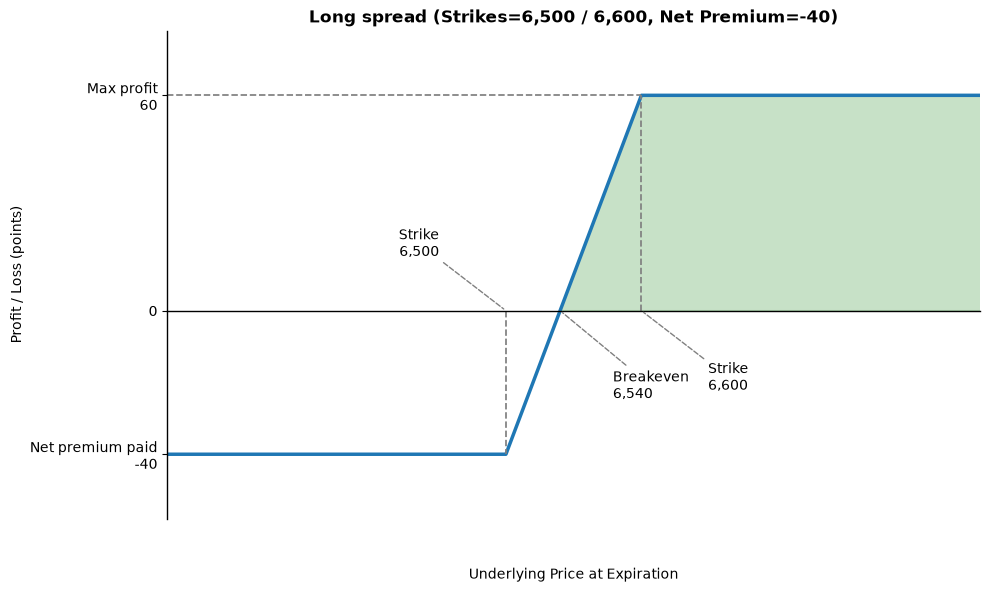

In [137]:
# Long spread (bull call spread): long 6,500 call + short 6,600 call
long_strike, long_premium = 6500, 260
short_strike, short_premium = 6600, 220
net_premium = short_premium - long_premium  # -40: net premium paid

long_call_pnl = np.maximum(prices - long_strike, 0) - long_premium
short_call_pnl = short_premium - np.maximum(prices - short_strike, 0)
pnl = long_call_pnl + short_call_pnl
breakeven = long_strike - net_premium

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(prices, pnl, color='tab:blue', linewidth=2.5)
ax.fill_between(prices, 0, pnl, where=pnl > 0, interpolate=True,
                color='forestgreen', alpha=0.25)

# Finite guides: strike-to-P/L verticals and the capped-profit horizontal.
for strike in (long_strike, short_strike):
    strike_pnl = np.interp(strike, prices, pnl)
    ax.vlines(strike, 0, strike_pnl, color='gray', linestyle='--', linewidth=1.25)
ax.hlines(np.interp(short_strike, prices, pnl), 6250, short_strike,
          color='gray', linestyle='--', linewidth=1.25)

ax.set_xlim(6250, 6850)
ax.set_ylim(-58, 78)
ax.set_xticks([])
max_profit = np.interp(short_strike, prices, pnl)
ax.set_yticks([net_premium, 0, max_profit],
              ['Net premium paid\n-40', '0', f'Max profit\n{max_profit:,.0f}'])

def add_price_annotation(text, price, offset):
    ax.annotate(
        text, xy=(price, 0), xytext=offset, textcoords='offset points',
        ha='left' if offset[0] > 0 else 'right',
        va='bottom' if offset[1] > 0 else 'top',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=1.5),
        arrowprops=dict(arrowstyle='-', color='gray', linestyle='--', linewidth=1),
    )

# Offsets deliberately place labels in separate quadrants away from the P/L line.
add_price_annotation('Strike\n6,500', long_strike, (-48, 36))
add_price_annotation('Breakeven\n6,540', breakeven, (38, -42))
add_price_annotation('Strike\n6,600', short_strike, (48, -36))

ax.set_title('Long spread (Strikes=6,500 / 6,600, Net Premium=-40)', fontweight='bold')
ax.set_xlabel('Underlying Price at Expiration')
ax.set_ylabel('Profit / Loss (points)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.xaxis.set_ticks_position('bottom')
ax.tick_params(axis='x', which='both', length=0)
ax.xaxis.set_label_coords(0.5, -0.1)
fig.tight_layout()
plt.show()


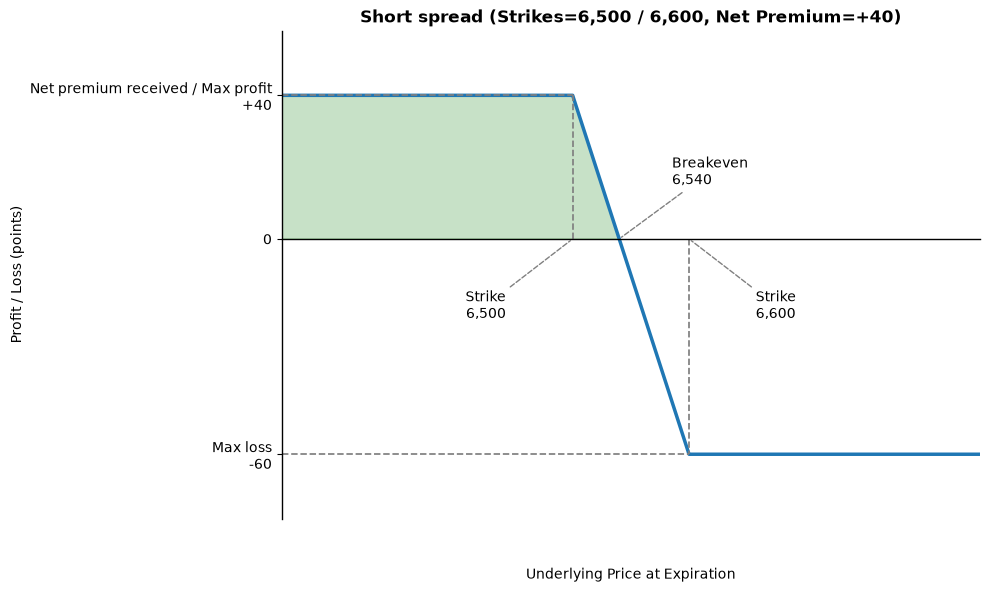

In [138]:
# Short spread (bear call spread): short 6,500 call + long 6,600 call
short_strike, short_premium = 6500, 260
long_strike, long_premium = 6600, 220
net_premium = short_premium - long_premium  # +40: net premium received

short_call_pnl = short_premium - np.maximum(prices - short_strike, 0)
long_call_pnl = np.maximum(prices - long_strike, 0) - long_premium
pnl = short_call_pnl + long_call_pnl
breakeven = short_strike + net_premium

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(prices, pnl, color='tab:blue', linewidth=2.5)
ax.fill_between(prices, 0, pnl, where=pnl > 0, interpolate=True,
                color='forestgreen', alpha=0.25)

# Finite guides: strike-to-P/L verticals and capped P/L horizontals.
for strike in (short_strike, long_strike):
    strike_pnl = np.interp(strike, prices, pnl)
    ax.vlines(strike, 0, strike_pnl, color='gray', linestyle='--', linewidth=1.25)
max_profit = np.interp(short_strike, prices, pnl)
max_loss = np.interp(long_strike, prices, pnl)
ax.hlines(max_profit, 6250, short_strike, color='gray', linestyle='--', linewidth=1.25)
ax.hlines(max_loss, 6250, long_strike, color='gray', linestyle='--', linewidth=1.25)

ax.set_xlim(6250, 6850)
ax.set_ylim(-78, 58)
ax.set_xticks([])
# Here the net premium received equals the maximum profit, so use one shared tick.
ax.set_yticks([max_loss, 0, net_premium],
              [f'Max loss\n{max_loss:,.0f}', '0',
               f'Net premium received / Max profit\n+{net_premium:,.0f}'])

def add_price_annotation(text, price, offset):
    ax.annotate(
        text, xy=(price, 0), xytext=offset, textcoords='offset points',
        ha='left' if offset[0] > 0 else 'right',
        va='bottom' if offset[1] > 0 else 'top',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=1.5),
        arrowprops=dict(arrowstyle='-', color='gray', linestyle='--', linewidth=1),
    )

add_price_annotation('Strike\n6,500', short_strike, (-48, -36))
add_price_annotation('Breakeven\n6,540', breakeven, (38, 36))
add_price_annotation('Strike\n6,600', long_strike, (48, -36))

ax.set_title('Short spread (Strikes=6,500 / 6,600, Net Premium=+40)', fontweight='bold')
ax.set_xlabel('Underlying Price at Expiration')
ax.set_ylabel('Profit / Loss (points)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.xaxis.set_ticks_position('bottom')
ax.tick_params(axis='x', which='both', length=0)
ax.xaxis.set_label_coords(0.5, -0.1)
fig.tight_layout()
plt.show()


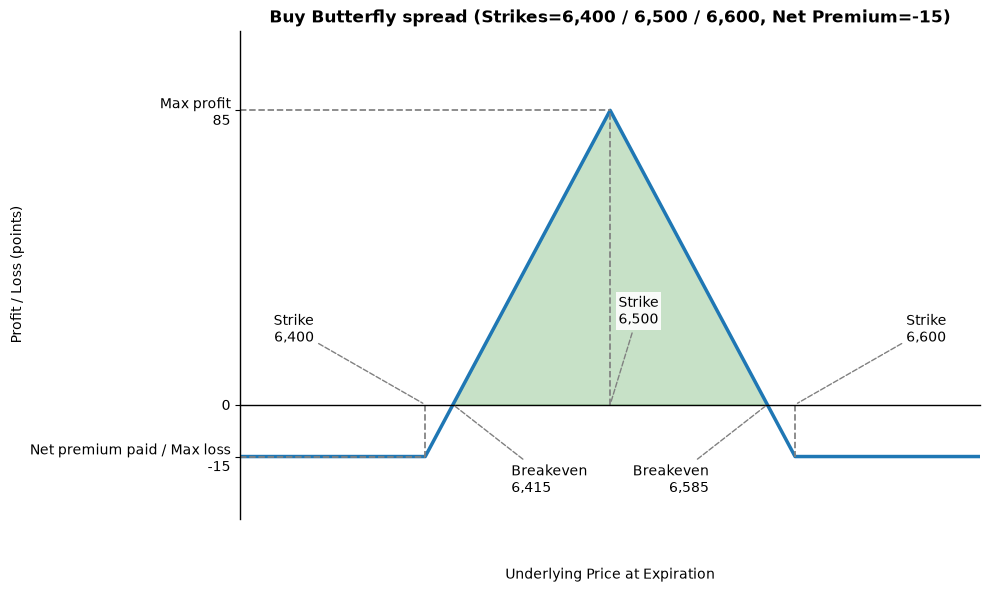

In [139]:
# Buy put butterfly: long 6,400 put + short 2 × 6,500 puts + long 6,600 put
lower_strike, middle_strike, upper_strike = 6400, 6500, 6600
net_premium = -15  # Premium paid; inferred from the supplied payoff example.

pnl = (np.maximum(lower_strike - prices, 0)
       - 2 * np.maximum(middle_strike - prices, 0)
       + np.maximum(upper_strike - prices, 0)
       + net_premium)
breakevens = (lower_strike - net_premium, upper_strike + net_premium)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(prices, pnl, color='tab:blue', linewidth=2.5)
ax.fill_between(prices, 0, pnl, where=pnl > 0, interpolate=True,
                color='forestgreen', alpha=0.25)

max_profit = np.interp(middle_strike, prices, pnl)
max_loss = net_premium
# Finite guides: vertical strike guides, plus key profit/loss heights from the y-axis.
for strike in (lower_strike, middle_strike, upper_strike):
    strike_pnl = np.interp(strike, prices, pnl)
    ax.vlines(strike, 0, strike_pnl, color='gray', linestyle='--', linewidth=1.25)
ax.hlines(max_loss, 6300, lower_strike, color='gray', linestyle='--', linewidth=1.25)
ax.hlines(max_profit, 6300, middle_strike, color='gray', linestyle='--', linewidth=1.25)

ax.set_xlim(6300, 6700)
ax.set_ylim(-33, 108)
ax.set_xticks([])
ax.set_yticks([max_loss, 0, max_profit],
              [f'Net premium paid / Max loss\n{max_loss:,.0f}', '0',
               f'Max profit\n{max_profit:,.0f}'])

def add_price_annotation(text, price, offset):
    ax.annotate(
        text, xy=(price, 0), xytext=offset, textcoords='offset points',
        ha='left' if offset[0] > 0 else 'right',
        va='bottom' if offset[1] > 0 else 'top',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=1.5),
        arrowprops=dict(arrowstyle='-', color='gray', linestyle='--', linewidth=1),
    )

# Use the empty loss area for edge labels; keep the centre strike above the profit peak.
add_price_annotation('Strike\n6,400', lower_strike, (-80, 42))
add_price_annotation('Breakeven\n6,415', breakevens[0], (42, -42))
add_price_annotation('Strike\n6,500', middle_strike, (6, 55))
add_price_annotation('Breakeven\n6,585', breakevens[1], (-42, -42))
add_price_annotation('Strike\n6,600', upper_strike, (80, 42))

ax.set_title('Buy Butterfly spread (Strikes=6,400 / 6,500 / 6,600, Net Premium=-15)',
             fontweight='bold')
ax.set_xlabel('Underlying Price at Expiration')
ax.set_ylabel('Profit / Loss (points)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.xaxis.set_ticks_position('bottom')
ax.tick_params(axis='x', which='both', length=0)
ax.xaxis.set_label_coords(0.5, -0.1)
fig.tight_layout()
plt.show()


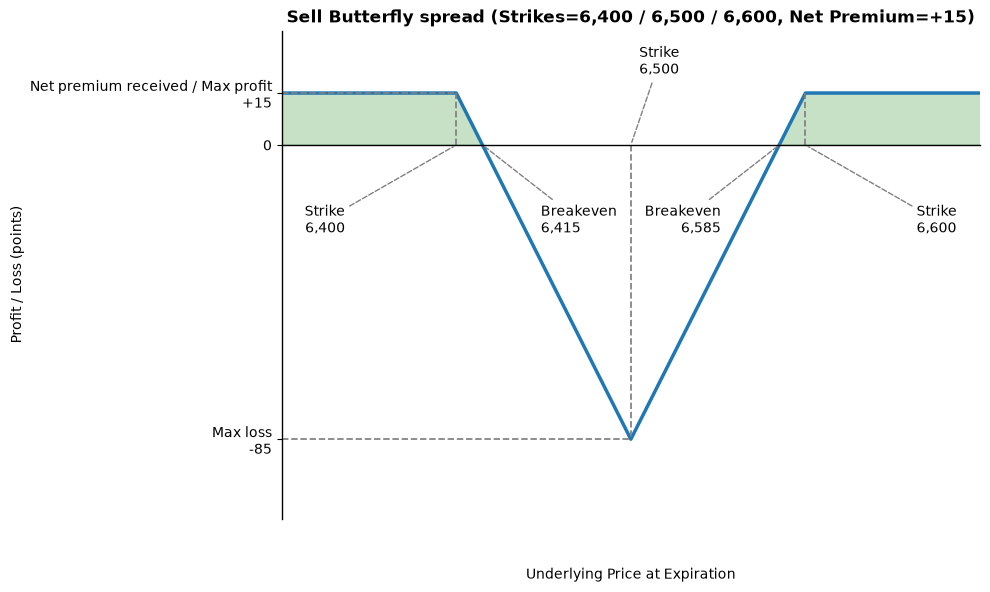

In [140]:
# Sell put butterfly: short 6,400 put + long 2 × 6,500 puts + short 6,600 put
lower_strike, middle_strike, upper_strike = 6400, 6500, 6600
net_premium = 15  # Premium received; opposite of the buy butterfly payoff.

pnl = (-np.maximum(lower_strike - prices, 0)
       + 2 * np.maximum(middle_strike - prices, 0)
       - np.maximum(upper_strike - prices, 0)
       + net_premium)
breakevens = (lower_strike + net_premium, upper_strike - net_premium)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(prices, pnl, color='tab:blue', linewidth=2.5)
ax.fill_between(prices, 0, pnl, where=pnl > 0, interpolate=True,
                color='forestgreen', alpha=0.25)

max_profit = net_premium
max_loss = np.interp(middle_strike, prices, pnl)
# Finite guides: vertical strike guides, plus key profit/loss heights from the y-axis.
for strike in (lower_strike, middle_strike, upper_strike):
    strike_pnl = np.interp(strike, prices, pnl)
    ax.vlines(strike, 0, strike_pnl, color='gray', linestyle='--', linewidth=1.25)
ax.hlines(max_profit, 6300, lower_strike, color='gray', linestyle='--', linewidth=1.25)
ax.hlines(max_loss, 6300, middle_strike, color='gray', linestyle='--', linewidth=1.25)

ax.set_xlim(6300, 6700)
ax.set_ylim(-108, 33)
ax.set_xticks([])
ax.set_yticks([max_loss, 0, net_premium],
              [f'Max loss\n{max_loss:,.0f}', '0',
               f'Net premium received / Max profit\n+{net_premium:,.0f}'])

def add_price_annotation(text, price, offset):
    ax.annotate(
        text, xy=(price, 0), xytext=offset, textcoords='offset points',
        ha='left' if offset[0] > 0 else 'right',
        va='bottom' if offset[1] > 0 else 'top',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=1.5),
        arrowprops=dict(arrowstyle='-', color='gray', linestyle='--', linewidth=1),
    )

# Edge labels use the empty loss area; the middle label uses the empty upper area.
add_price_annotation('Strike\n6,400', lower_strike, (-80, -42))
add_price_annotation('Breakeven\n6,415', breakevens[0], (42, -42))
add_price_annotation('Strike\n6,500', middle_strike, (6, 48))
add_price_annotation('Breakeven\n6,585', breakevens[1], (-42, -42))
add_price_annotation('Strike\n6,600', upper_strike, (80, -42))

ax.set_title('Sell Butterfly spread (Strikes=6,400 / 6,500 / 6,600, Net Premium=+15)',
             fontweight='bold')
ax.set_xlabel('Underlying Price at Expiration')
ax.set_ylabel('Profit / Loss (points)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.xaxis.set_ticks_position('bottom')
ax.tick_params(axis='x', which='both', length=0)
ax.xaxis.set_label_coords(0.5, -0.1)
fig.tight_layout()
plt.show()


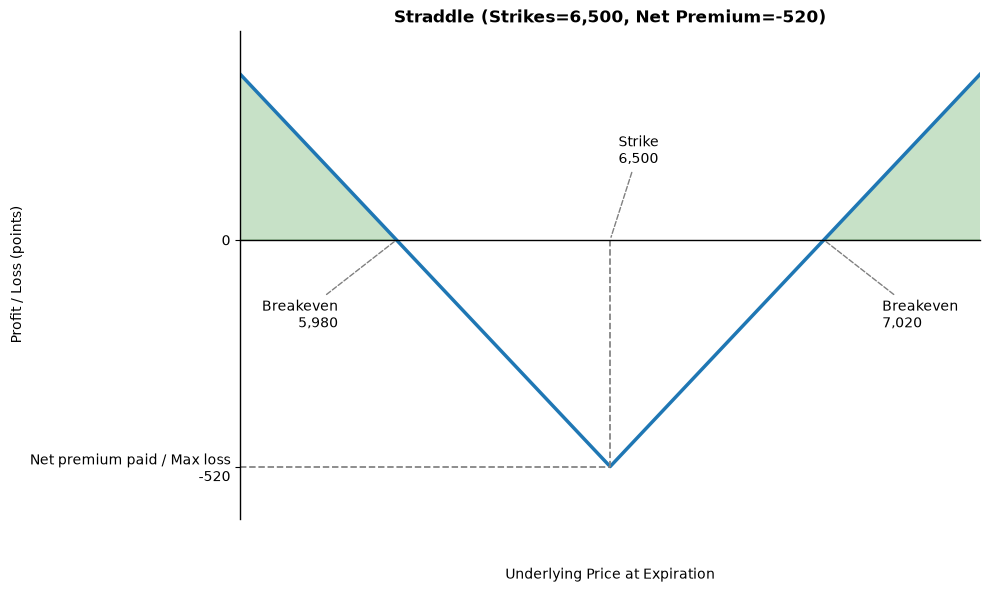

In [141]:
# Long straddle: long 6,500 call + long 6,500 put
strike = 6500
call_premium = put_premium = 260
net_premium = -(call_premium + put_premium)  # -520: net premium paid

pnl = (np.maximum(prices - strike, 0) - call_premium
       + np.maximum(strike - prices, 0) - put_premium)
breakevens = (strike + net_premium, strike - net_premium)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(prices, pnl, color='tab:blue', linewidth=2.5)
ax.fill_between(prices, 0, pnl, where=pnl > 0, interpolate=True,
                color='forestgreen', alpha=0.25)

max_loss = np.interp(strike, prices, pnl)
# Finite guides: the strike-to-P/L vertical and the maximum-loss height.
ax.vlines(strike, 0, max_loss, color='gray', linestyle='--', linewidth=1.25)
ax.hlines(max_loss, 5600, strike, color='gray', linestyle='--', linewidth=1.25)

ax.set_xlim(5600, 7400)
ax.set_ylim(-640, 480)
ax.set_xticks([])
ax.set_yticks([net_premium, 0], ['Net premium paid / Max loss\n-520', '0'])

def add_price_annotation(text, price, offset):
    ax.annotate(
        text, xy=(price, 0), xytext=offset, textcoords='offset points',
        ha='left' if offset[0] > 0 else 'right',
        va='bottom' if offset[1] > 0 else 'top',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=1.5),
        arrowprops=dict(arrowstyle='-', color='gray', linestyle='--', linewidth=1),
    )

# Place labels in the central loss area, away from the two green profit regions.
add_price_annotation('Breakeven\n5,980', breakevens[0], (-42, -42))
add_price_annotation('Strike\n6,500', strike, (6, 52))
add_price_annotation('Breakeven\n7,020', breakevens[1], (42, -42))

ax.set_title('Straddle (Strikes=6,500, Net Premium=-520)', fontweight='bold')
ax.set_xlabel('Underlying Price at Expiration')
ax.set_ylabel('Profit / Loss (points)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.xaxis.set_ticks_position('bottom')
ax.tick_params(axis='x', which='both', length=0)
ax.xaxis.set_label_coords(0.5, -0.1)
fig.tight_layout()
plt.show()


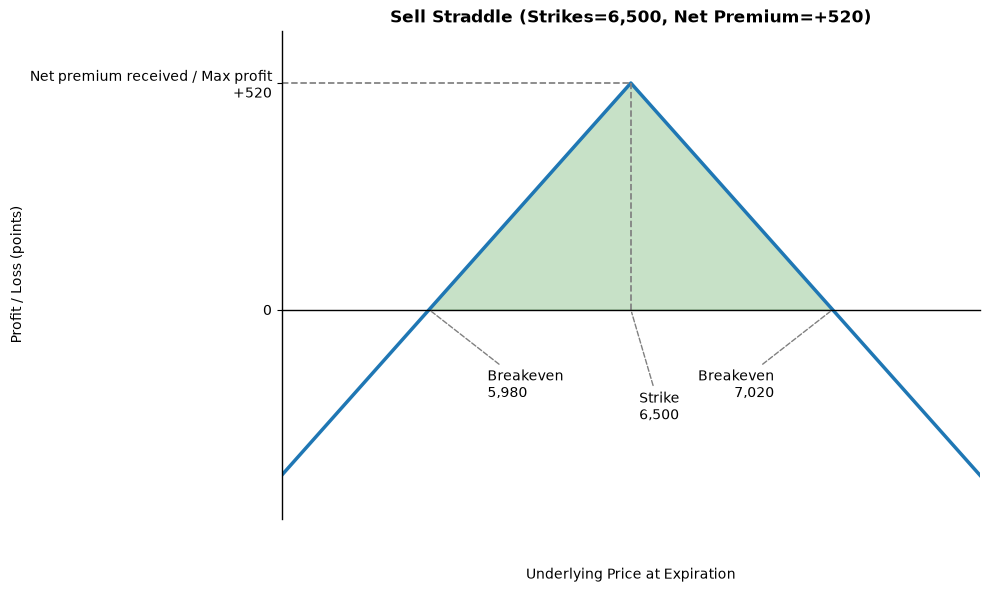

In [142]:
# Sell straddle: short 6,500 call + short 6,500 put
strike = 6500
call_premium = put_premium = 260
net_premium = call_premium + put_premium  # +520: net premium received

pnl = (call_premium - np.maximum(prices - strike, 0)
       + put_premium - np.maximum(strike - prices, 0))
breakevens = (strike - net_premium, strike + net_premium)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(prices, pnl, color='tab:blue', linewidth=2.5)
ax.fill_between(prices, 0, pnl, where=pnl > 0, interpolate=True,
                color='forestgreen', alpha=0.25)

max_profit = np.interp(strike, prices, pnl)
# Finite guides: the strike-to-P/L vertical and the maximum-profit height.
ax.vlines(strike, 0, max_profit, color='gray', linestyle='--', linewidth=1.25)
ax.hlines(max_profit, 5600, strike, color='gray', linestyle='--', linewidth=1.25)

ax.set_xlim(5600, 7400)
ax.set_ylim(-480, 640)
ax.set_xticks([])
ax.set_yticks([0, net_premium],
              ['0', f'Net premium received / Max profit\n+{net_premium:,.0f}'])

def add_price_annotation(text, price, offset):
    ax.annotate(
        text, xy=(price, 0), xytext=offset, textcoords='offset points',
        ha='left' if offset[0] > 0 else 'right',
        va='bottom' if offset[1] > 0 else 'top',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=1.5),
        arrowprops=dict(arrowstyle='-', color='gray', linestyle='--', linewidth=1),
    )

# Place labels below the x-axis, outside the central green profit area.
add_price_annotation('Breakeven\n5,980', breakevens[0], (42, -42))
add_price_annotation('Strike\n6,500', strike, (6, -58))
add_price_annotation('Breakeven\n7,020', breakevens[1], (-42, -42))

ax.set_title('Sell Straddle (Strikes=6,500, Net Premium=+520)', fontweight='bold')
ax.set_xlabel('Underlying Price at Expiration')
ax.set_ylabel('Profit / Loss (points)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.xaxis.set_ticks_position('bottom')
ax.tick_params(axis='x', which='both', length=0)
ax.xaxis.set_label_coords(0.5, -0.1)
fig.tight_layout()
plt.show()


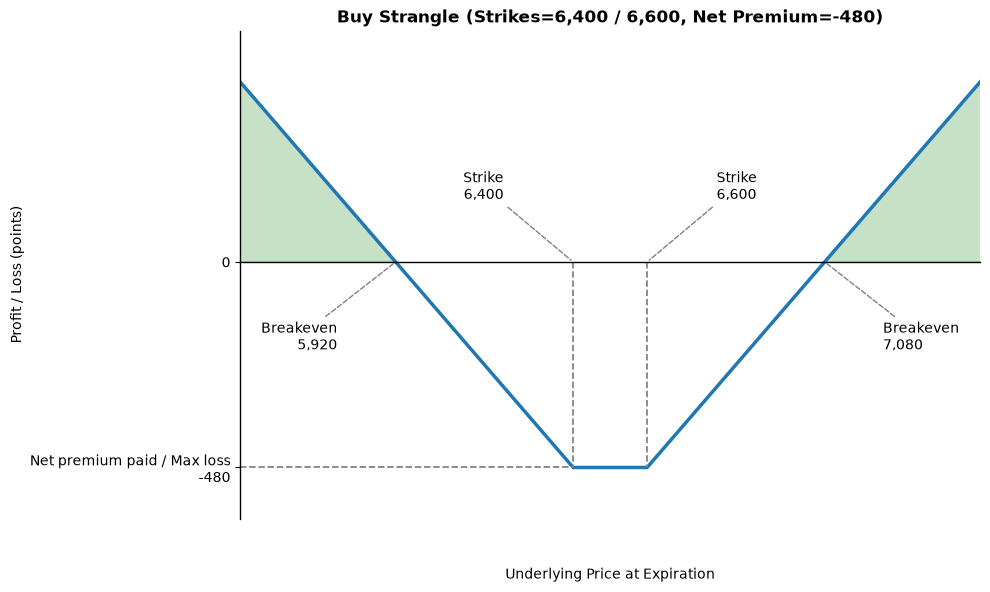

In [143]:
# Buy strangle: long 6,400 put + long 6,600 call
put_strike, call_strike = 6400, 6600
put_premium = call_premium = 240
net_premium = -(put_premium + call_premium)  # -480: net premium paid

pnl = (np.maximum(put_strike - prices, 0) - put_premium
       + np.maximum(prices - call_strike, 0) - call_premium)
breakevens = (put_strike + net_premium, call_strike - net_premium)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(prices, pnl, color='tab:blue', linewidth=2.5)
ax.fill_between(prices, 0, pnl, where=pnl > 0, interpolate=True,
                color='forestgreen', alpha=0.25)

max_loss = net_premium
# Finite guides: strike-to-P/L verticals and the maximum-loss height.
for strike in (put_strike, call_strike):
    strike_pnl = np.interp(strike, prices, pnl)
    ax.vlines(strike, 0, strike_pnl, color='gray', linestyle='--', linewidth=1.25)
ax.hlines(max_loss, 5500, put_strike, color='gray', linestyle='--', linewidth=1.25)

ax.set_xlim(5500, 7500)
ax.set_ylim(-600, 540)
ax.set_xticks([])
ax.set_yticks([net_premium, 0],
              [f'Net premium paid / Max loss\n{net_premium:,.0f}', '0'])

def add_price_annotation(text, price, offset):
    ax.annotate(
        text, xy=(price, 0), xytext=offset, textcoords='offset points',
        ha='left' if offset[0] > 0 else 'right',
        va='bottom' if offset[1] > 0 else 'top',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=1.5),
        arrowprops=dict(arrowstyle='-', color='gray', linestyle='--', linewidth=1),
    )

# Labels occupy local quadrants without payoff lines or green fill.
add_price_annotation('Breakeven\n5,920', breakevens[0], (-42, -42))
add_price_annotation('Strike\n6,400', put_strike, (-50, 42))
add_price_annotation('Strike\n6,600', call_strike, (50, 42))
add_price_annotation('Breakeven\n7,080', breakevens[1], (42, -42))

ax.set_title('Buy Strangle (Strikes=6,400 / 6,600, Net Premium=-480)', fontweight='bold')
ax.set_xlabel('Underlying Price at Expiration')
ax.set_ylabel('Profit / Loss (points)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.xaxis.set_ticks_position('bottom')
ax.tick_params(axis='x', which='both', length=0)
ax.xaxis.set_label_coords(0.5, -0.1)
fig.tight_layout()
plt.show()


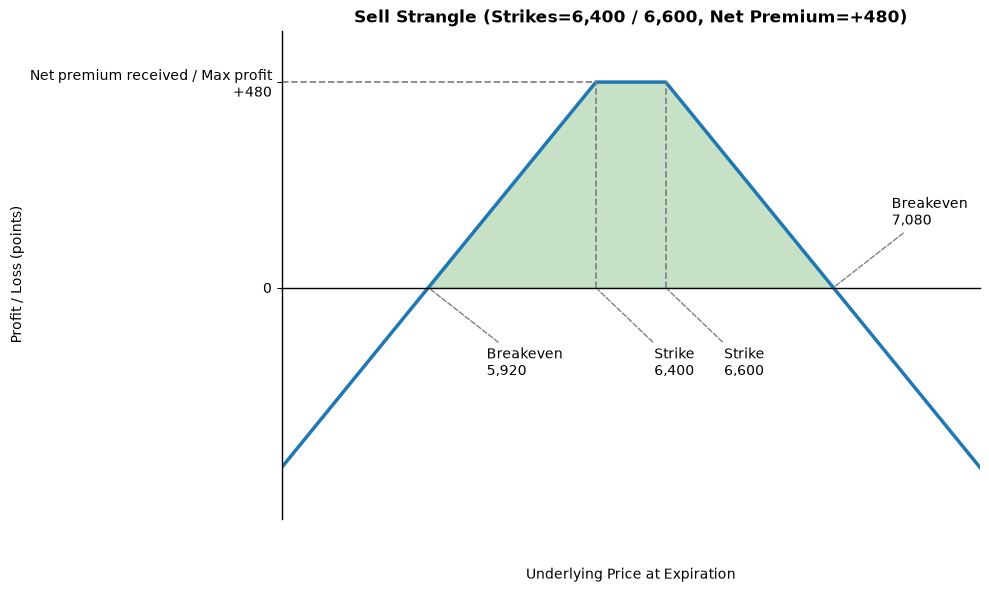

In [144]:
# Sell strangle: short 6,400 put + short 6,600 call
put_strike, call_strike = 6400, 6600
put_premium = call_premium = 240
net_premium = put_premium + call_premium  # +480: net premium received

pnl = (put_premium - np.maximum(put_strike - prices, 0)
       + call_premium - np.maximum(prices - call_strike, 0))
breakevens = (put_strike - net_premium, call_strike + net_premium)

fig, ax = plt.subplots(figsize=(10, 6))
pnl_line, = ax.plot(prices, pnl, color='tab:blue', linewidth=2.5)
profit_fill = ax.fill_between(prices, 0, pnl, where=pnl > 0, interpolate=True,
                              color='forestgreen', alpha=0.25)

max_profit = net_premium
# Finite guides: strike-to-P/L verticals and the maximum-profit height.
guide_artists = []
for strike in (put_strike, call_strike):
    strike_pnl = np.interp(strike, prices, pnl)
    guide_artists.append(
        ax.vlines(strike, 0, strike_pnl, color='gray', linestyle='--', linewidth=1.25)
    )
guide_artists.append(
    ax.hlines(max_profit, 5500, put_strike,
              color='gray', linestyle='--', linewidth=1.25)
)

ax.set_xlim(5500, 7500)
ax.set_ylim(-540, 600)
ax.set_xticks([])
ax.set_yticks([0, net_premium],
              ['0', f'Net premium received / Max profit\n+{net_premium:,.0f}'])

annotation_specs = [
    (f'Breakeven\n{breakevens[0]:,.0f}', breakevens[0]),
    (f'Strike\n{put_strike:,.0f}', put_strike),
    (f'Strike\n{call_strike:,.0f}', call_strike),
    (f'Breakeven\n{breakevens[1]:,.0f}', breakevens[1]),
]


def place_annotations_without_overlap(ax, specs, pnl_line, profit_fill, guides):
    """Choose a collision-free global combination from rendered candidates."""
    from itertools import product

    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    canvas = fig.bbox

    protected_paths = [
        (pnl_line.get_path().transformed(pnl_line.get_transform()), False),
    ]
    protected_paths.extend(
        (path.transformed(profit_fill.get_transform()), True)
        for path in profit_fill.get_paths()
    )
    for artist in guides:
        protected_paths.extend(
            (path.transformed(artist.get_transform()), False)
            for path in artist.get_paths()
        )
    for spine_name in ('left', 'bottom'):
        spine = ax.spines[spine_name]
        protected_paths.append(
            (spine.get_path().transformed(spine.get_transform()), False)
        )

    static_text = [*ax.get_yticklabels(), ax.xaxis.label, ax.yaxis.label, ax.title]
    static_boxes = [
        text.get_window_extent(renderer).expanded(1.08, 1.15)
        for text in static_text if text.get_visible() and text.get_text()
    ]

    directions = [(-1, -1), (1, -1), (-1, 1), (1, 1)]
    offsets = [(sx * distance, sy * distance)
               for distance in (42, 62, 84)
               for sx, sy in directions]

    def make_annotation(text, price, offset):
        return ax.annotate(
            text, xy=(price, 0), xytext=offset, textcoords='offset points',
            ha='left' if offset[0] > 0 else 'right',
            va='bottom' if offset[1] > 0 else 'top',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=1.5),
            arrowprops=dict(arrowstyle='-', color='gray',
                            linestyle='--', linewidth=1),
        )

    candidates = []
    for text, price in specs:
        label_candidates = []
        for offset in offsets:
            annotation = make_annotation(text, price, offset)
            fig.canvas.draw()
            bbox = annotation.get_bbox_patch().get_window_extent(renderer).expanded(1.10, 1.16)
            arrow_path = annotation.arrow_patch.get_path().transformed(
                annotation.arrow_patch.get_transform()
            )
            outside_canvas = not (
                canvas.x0 <= bbox.x0 and bbox.x1 <= canvas.x1
                and canvas.y0 <= bbox.y0 and bbox.y1 <= canvas.y1
            )
            fixed_hits = int(outside_canvas)
            fixed_hits += sum(
                path.intersects_bbox(bbox, filled=filled)
                for path, filled in protected_paths
            )
            fixed_hits += sum(bbox.overlaps(other) for other in static_boxes)
            label_candidates.append(dict(
                offset=offset, bbox=bbox, arrow=arrow_path, fixed_hits=fixed_hits
            ))
            annotation.remove()
        candidates.append(label_candidates)

    def pair_hits(first, second):
        return (
            int(first['bbox'].overlaps(second['bbox']))
            + int(first['arrow'].intersects_bbox(second['bbox']))
            + int(second['arrow'].intersects_bbox(first['bbox']))
            + int(first['arrow'].intersects_path(second['arrow'], filled=False))
        )

    best_choice = None
    best_score = None
    candidate_indexes = range(len(offsets))
    for choice in product(candidate_indexes, repeat=len(specs)):
        selected = [candidates[i][index] for i, index in enumerate(choice)]
        collisions = sum(item['fixed_hits'] for item in selected)
        collisions += sum(
            pair_hits(selected[i], selected[j])
            for i in range(len(selected))
            for j in range(i + 1, len(selected))
        )
        leader_length = sum(np.hypot(*item['offset']) for item in selected)
        score = (collisions, leader_length)
        if best_score is None or score < best_score:
            best_score, best_choice = score, choice

    if best_score[0] != 0:
        raise RuntimeError('No collision-free annotation layout found; expand limits or offsets.')

    annotations = [
        make_annotation(text, price, candidates[i][best_choice[i]]['offset'])
        for i, (text, price) in enumerate(specs)
    ]
    fig.canvas.draw()
    final_boxes = [
        annotation.get_bbox_patch().get_window_extent(fig.canvas.get_renderer())
        for annotation in annotations
    ]
    assert not any(
        final_boxes[i].overlaps(final_boxes[j])
        for i in range(len(final_boxes))
        for j in range(i + 1, len(final_boxes))
    ), 'Annotation collision detected after final render.'
    return annotations

ax.set_title('Sell Strangle (Strikes=6,400 / 6,600, Net Premium=+480)', fontweight='bold')
ax.set_xlabel('Underlying Price at Expiration')
ax.set_ylabel('Profit / Loss (points)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.xaxis.set_ticks_position('bottom')
ax.tick_params(axis='x', which='both', length=0)
ax.xaxis.set_label_coords(0.5, -0.1)
fig.tight_layout()
annotations = place_annotations_without_overlap(
    ax, annotation_specs, pnl_line, profit_fill, guide_artists
)
fig.canvas.draw()
plt.show()


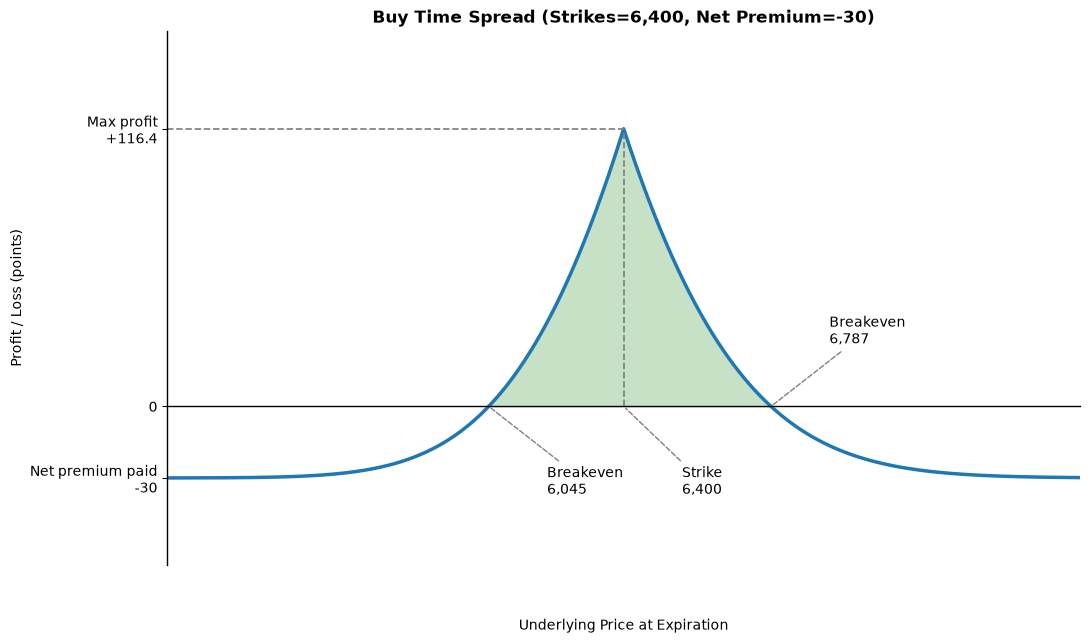

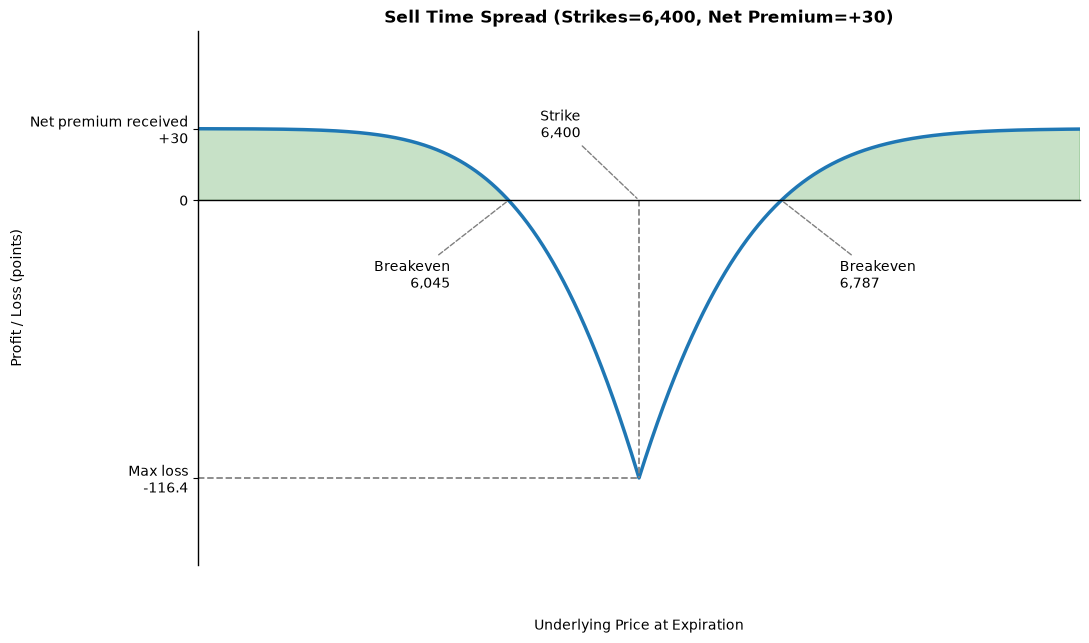

In [145]:
# Time-spread P/L at the front-month expiration.
# Supplied data: K=6,400, front premium=50, back premium=80.
# Assumptions needed to value the unexpired back-month call:
# 30 days remaining, 20% annual volatility, 0% risk-free rate/dividend yield.
from math import erf

time_spread_strike = 6400
front_month_premium, back_month_premium = 50, 80
remaining_days = 30
annual_volatility = 0.20
risk_free_rate = dividend_yield = 0.0
time_prices = np.linspace(5200, 7600, 2401)


def normal_cdf(values):
    return 0.5 * (1.0 + np.vectorize(erf)(values / np.sqrt(2.0)))


def black_scholes_call(spot, strike, time, rate, volatility, dividend=0.0):
    sqrt_time = np.sqrt(time)
    d1 = (np.log(spot / strike)
          + (rate - dividend + 0.5 * volatility ** 2) * time)
    d1 /= volatility * sqrt_time
    d2 = d1 - volatility * sqrt_time
    return (spot * np.exp(-dividend * time) * normal_cdf(d1)
            - strike * np.exp(-rate * time) * normal_cdf(d2))


def zero_crossings(x, y):
    """Linearly interpolate every zero crossing of a sampled curve."""
    roots = []
    crossing_indexes = np.flatnonzero(np.signbit(y[:-1]) != np.signbit(y[1:]))
    for index in crossing_indexes:
        x0, x1 = x[index:index + 2]
        y0, y1 = y[index:index + 2]
        roots.append(x0 - y0 * (x1 - x0) / (y1 - y0))
    return roots


time_to_expiry = remaining_days / 365.0
back_call_at_front_expiry = black_scholes_call(
    time_prices, time_spread_strike, time_to_expiry,
    risk_free_rate, annual_volatility, dividend_yield
)
front_call_intrinsic = np.maximum(time_prices - time_spread_strike, 0.0)
buy_net_premium = front_month_premium - back_month_premium  # -30
buy_time_spread_pnl = (back_call_at_front_expiry - front_call_intrinsic
                       + buy_net_premium)


def plot_time_spread(strategy_name, pnl, net_premium):
    breakevens = zero_crossings(time_prices, pnl)
    strike_pnl = float(np.interp(time_spread_strike, time_prices, pnl))
    key_pnl_name = 'Max profit' if strike_pnl > 0 else 'Max loss'

    fig, ax = plt.subplots(figsize=(11, 6.5))
    pnl_line, = ax.plot(time_prices, pnl, color='tab:blue', linewidth=2.5)
    profit_fill = ax.fill_between(
        time_prices, 0, pnl, where=pnl > 0, interpolate=True,
        color='forestgreen', alpha=0.25
    )

    # Finite guides: the strike-to-P/L vertical and the key height from y-axis.
    guide_artists = [
        ax.vlines(time_spread_strike, 0, strike_pnl, color='gray',
                  linestyle='--', linewidth=1.25),
        ax.hlines(strike_pnl, time_prices.min(), time_spread_strike,
                  color='gray', linestyle='--', linewidth=1.25),
    ]

    y_span = float(pnl.max() - pnl.min())
    ax.set_xlim(time_prices.min(), time_prices.max())
    ax.set_ylim(float(pnl.min() - 0.25 * y_span),
                float(pnl.max() + 0.28 * y_span))
    ax.set_xticks([])

    premium_name = ('Net premium received' if net_premium > 0
                    else 'Net premium paid')
    y_ticks = sorted([float(net_premium), 0.0, strike_pnl])
    y_labels = []
    for value in y_ticks:
        if np.isclose(value, net_premium):
            y_labels.append(f'{premium_name}\n{value:+,.0f}')
        elif np.isclose(value, strike_pnl):
            y_labels.append(f'{key_pnl_name}\n{value:+,.1f}')
        else:
            y_labels.append('0')
    ax.set_yticks(y_ticks, y_labels)

    annotation_specs = [
        (f'Breakeven\n{breakeven:,.0f}', breakeven)
        for breakeven in breakevens
    ]
    annotation_specs.insert(
        len(annotation_specs) // 2,
        (f'Strike\n{time_spread_strike:,.0f}', time_spread_strike),
    )

    ax.set_title(
        f'{strategy_name} (Strikes={time_spread_strike:,.0f}, '
        f'Net Premium={net_premium:+,.0f})',
        fontweight='bold'
    )
    ax.set_xlabel('Underlying Price at Expiration')
    ax.set_ylabel('Profit / Loss (points)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position(('data', 0))
    ax.spines['bottom'].set_linewidth(1)
    ax.spines['left'].set_linewidth(1)
    ax.xaxis.set_ticks_position('bottom')
    ax.tick_params(axis='x', which='both', length=0)
    ax.xaxis.set_label_coords(0.5, -0.1)
    fig.tight_layout()

    place_annotations_without_overlap(
        ax, annotation_specs, pnl_line, profit_fill, guide_artists
    )
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    visible_text = [*ax.texts, *ax.get_yticklabels(),
                    ax.xaxis.label, ax.yaxis.label, ax.title]
    for artist in visible_text:
        if artist.get_visible() and artist.get_text():
            box = artist.get_window_extent(renderer)
            assert fig.bbox.contains(box.x0, box.y0)
            assert fig.bbox.contains(box.x1, box.y1)
    plt.show()


plot_time_spread('Buy Time Spread', buy_time_spread_pnl, buy_net_premium)
plot_time_spread('Sell Time Spread', -buy_time_spread_pnl, -buy_net_premium)


# Synthetic Long Future: Buy Call + Sell Put

同一履約價買進 Call、賣出 Put，損益等同於合成多頭期貨。

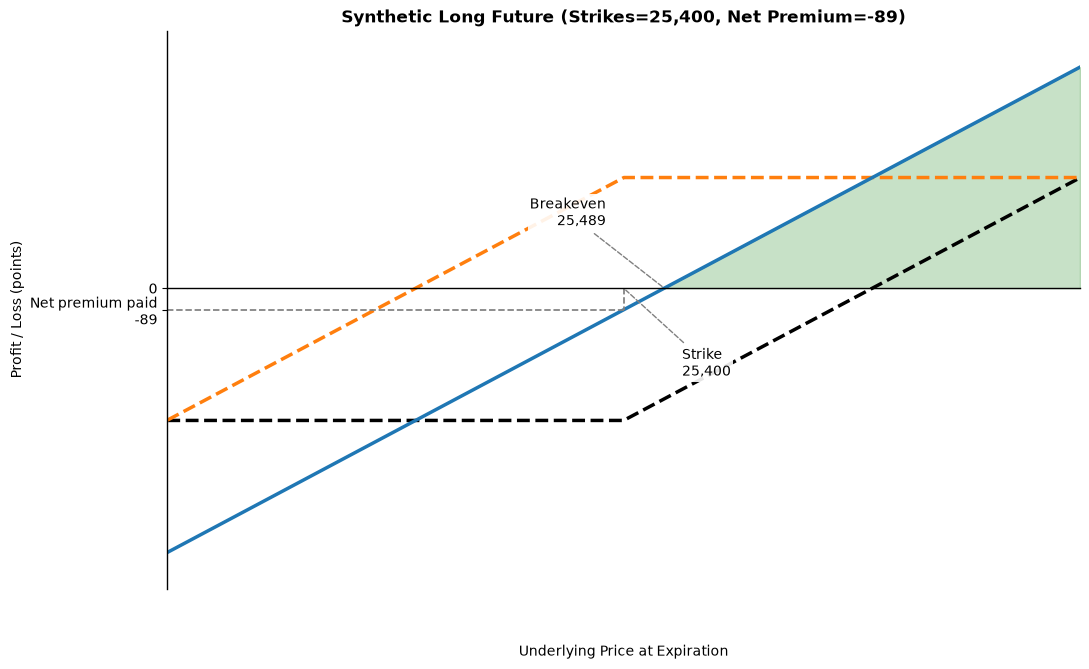

In [146]:
from pathlib import Path
import pandas as pd

# Use executable prices at the strike closest to the quoted underlying index:
# buy the Call at its ask and sell the Put at its bid.
quote_path = Path('txo_2025-09-17_1334_2025-10_quotes.csv')
if not quote_path.exists():
    quote_path = Path('HW3') / quote_path
quotes = pd.read_csv(quote_path)
underlying = float(quotes['underlying_index'].iloc[0])
strike = int(quotes.loc[(quotes['strike_price'] - underlying).abs().idxmin(), 'strike_price'])
row = quotes.loc[quotes['strike_price'].eq(strike)].iloc[0]
call_premium = float(row['call_ask'])
put_premium = float(row['put_bid'])
net_premium = put_premium - call_premium  # -89: paid
breakeven = strike - net_premium

synthetic_prices = np.linspace(strike - 1000, strike + 1000, 4001)
buy_call_pnl = np.maximum(synthetic_prices - strike, 0) - call_premium
sell_put_pnl = put_premium - np.maximum(strike - synthetic_prices, 0)
synthetic_pnl = buy_call_pnl + sell_put_pnl

fig, ax = plt.subplots(figsize=(11, 6.8))
# Component curves make the synthetic construction explicit; no legend is used.
ax.plot(synthetic_prices, buy_call_pnl, color='black', linestyle='--', linewidth=2.5)
ax.plot(synthetic_prices, sell_put_pnl, color='tab:orange', linestyle='--', linewidth=2.5)
pnl_line, = ax.plot(synthetic_prices, synthetic_pnl, color='tab:blue', linewidth=2.5)
profit_fill = ax.fill_between(synthetic_prices, 0, synthetic_pnl,
                              where=synthetic_pnl > 0, interpolate=True,
                              color='forestgreen', alpha=0.25)

# Finite guides only: the strike's P/L and its key P/L height.
strike_pnl = float(np.interp(strike, synthetic_prices, synthetic_pnl))
guide_artists = [
    ax.vlines(strike, 0, strike_pnl, color='gray', linestyle='--', linewidth=1.25),
    ax.hlines(strike_pnl, synthetic_prices.min(), strike,
              color='gray', linestyle='--', linewidth=1.25),
]

ax.set_xlim(synthetic_prices.min(), synthetic_prices.max())
ax.set_ylim(synthetic_pnl.min() - 150, synthetic_pnl.max() + 150)
ax.set_xticks([])
ax.set_yticks([net_premium, 0],
              [f'Net premium paid\n{net_premium:+,.0f}', '0'])
ax.set_title(f'Synthetic Long Future (Strikes={strike:,.0f}, Net Premium={net_premium:+,.0f})',
             fontweight='bold')
ax.set_xlabel('Underlying Price at Expiration')
ax.set_ylabel('Profit / Loss (points)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.xaxis.set_ticks_position('bottom')
ax.tick_params(axis='x', which='both', length=0)
ax.xaxis.set_label_coords(0.5, -0.10)
fig.tight_layout()

# Defined above in the Sell Strangle cell: renderer-based global placement.
place_annotations_without_overlap(
    ax,
    [(f'Strike\n{strike:,.0f}', strike),
     (f'Breakeven\n{breakeven:,.0f}', breakeven)],
    pnl_line, profit_fill, guide_artists,
)
fig.tight_layout()
fig.canvas.draw()
plt.show()


# Synthetic Short Future: Sell Call + Buy Put

同一履約價賣出 Call、買進 Put，損益等同於合成空頭期貨。

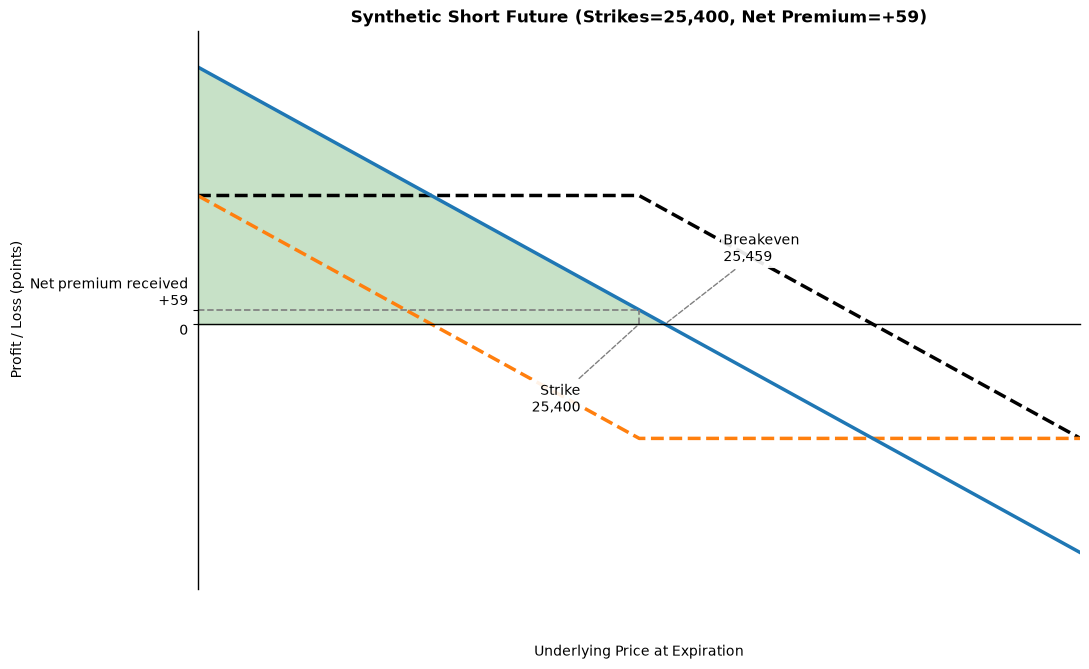

In [147]:
# Use executable prices: sell the Call at its bid and buy the Put at its ask.
short_quotes = pd.read_csv(quote_path)
short_underlying = float(short_quotes['underlying_index'].iloc[0])
short_strike = int(short_quotes.loc[
    (short_quotes['strike_price'] - short_underlying).abs().idxmin(), 'strike_price'
])
short_row = short_quotes.loc[short_quotes['strike_price'].eq(short_strike)].iloc[0]
short_call_premium = float(short_row['call_bid'])
long_put_premium = float(short_row['put_ask'])
short_net_premium = short_call_premium - long_put_premium  # +59: received
short_breakeven = short_strike + short_net_premium

short_prices = np.linspace(short_strike - 1000, short_strike + 1000, 4001)
sell_call_pnl = short_call_premium - np.maximum(short_prices - short_strike, 0)
buy_put_pnl = np.maximum(short_strike - short_prices, 0) - long_put_premium
short_pnl = sell_call_pnl + buy_put_pnl

fig, ax = plt.subplots(figsize=(11, 6.8))
# Component curves make the synthetic construction explicit; no legend is used.
ax.plot(short_prices, sell_call_pnl, color='black', linestyle='--', linewidth=2.5)
ax.plot(short_prices, buy_put_pnl, color='tab:orange', linestyle='--', linewidth=2.5)
pnl_line, = ax.plot(short_prices, short_pnl, color='tab:blue', linewidth=2.5)
profit_fill = ax.fill_between(short_prices, 0, short_pnl, where=short_pnl > 0,
                              interpolate=True, color='forestgreen', alpha=0.25)

short_strike_pnl = float(np.interp(short_strike, short_prices, short_pnl))
guide_artists = [
    ax.vlines(short_strike, 0, short_strike_pnl, color='gray', linestyle='--', linewidth=1.25),
    ax.hlines(short_strike_pnl, short_prices.min(), short_strike,
              color='gray', linestyle='--', linewidth=1.25),
]

ax.set_xlim(short_prices.min(), short_prices.max())
ax.set_ylim(short_pnl.min() - 150, short_pnl.max() + 150)
ax.set_xticks([])
ax.set_yticks([0, short_net_premium],
              ['0', f'Net premium received\n{short_net_premium:+,.0f}'])
# The two key P/L levels are close together, so push their tick labels apart.
zero_tick, premium_tick = ax.get_yticklabels()
zero_tick.set_verticalalignment('top')
premium_tick.set_verticalalignment('bottom')
ax.set_title(
    f'Synthetic Short Future (Strikes={short_strike:,.0f}, Net Premium={short_net_premium:+,.0f})',
    fontweight='bold',
)
ax.set_xlabel('Underlying Price at Expiration')
ax.set_ylabel('Profit / Loss (points)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.xaxis.set_ticks_position('bottom')
ax.tick_params(axis='x', which='both', length=0)
ax.xaxis.set_label_coords(0.5, -0.10)
fig.tight_layout()

place_annotations_without_overlap(
    ax,
    [(f'Strike\n{short_strike:,.0f}', short_strike),
     (f'Breakeven\n{short_breakeven:,.0f}', short_breakeven)],
    pnl_line, profit_fill, guide_artists,
)
fig.tight_layout()
fig.canvas.draw()
plt.show()
